# 0. Notebook 01 - Divisão Estratificada Inicial (Holdout)

## 1. Pré-processamento, EDA e Blindagem contra Data Leakage

### 📌 Objetivos
1. **Carga dos Dados Brutos:** Importar o dataset de notícias (`FakeRecogna.xlsx`).
2. **Higienização Textual (NLP):** Limpar o texto removendo ruídos (URLs, pontuações, números e *stopwords*).
3. **Análise Exploratória de Dados (EDA):** Inspecionar a distribuição das classes e o tamanho das notícias.
4. **Divisão Estratificada (Holdout):** Separar 80% para treino/validação cruzada e 20% para o teste final antes de qualquer vetorização estatística (evitando *Data Leakage*).
5. **Exportação:** Salvar os datasets limpos em arquivos CSV.

In [1]:
%pip install nltk
import os
import re
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Download das Stopwords do NLTK (se necessário)
nltk.download("stopwords", quiet=True)
stopwords_pt = set(stopwords.words("portuguese"))

print("✅ Bibliotecas e recursos de PLN carregados com sucesso!")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Bibliotecas e recursos de PLN carregados com sucesso!


## 2. Carga dos Dados Brutos

### Carregamento da base original e verificação da estrutura das colunas, dados nulos e formato inicial.

In [2]:
import os
import pandas as pd

# Nome do arquivo que estamos procurando
nome_arquivo = "FakeRecogna.xlsx"
caminho_encontrado = None

# Varre a árvore de diretórios a partir do diretório atual e subindo níveis
diretorio_busca = os.getcwd()
for _ in range(4):  # Sobe até 4 níveis para garantir que alcança a raiz
  caminho_atual = os.path.join(diretorio_busca, nome_arquivo)
  # Procura também na estrutura padrão data/raw/
  caminho_data_raw = os.path.join(diretorio_busca, "data", "raw", nome_arquivo)

  if os.path.exists(caminho_data_raw):
    caminho_encontrado = caminho_data_raw
    break
  elif os.path.exists(caminho_atual):
    caminho_encontrado = caminho_atual
    break

  # Sobe um nível na árvore de pastas
  diretorio_busca = os.path.dirname(diretorio_busca)

# Busca recursiva global caso os caminhos diretos falhem
if not caminho_encontrado:
  for root, dirs, files in os.walk(os.path.abspath(os.path.join(os.getcwd(), "../.."))):
    if nome_arquivo in files:
      caminho_encontrado = os.path.join(root, nome_arquivo)
      break

# Carrega o arquivo ou exibe o diagnóstico exato se falhar
if caminho_encontrado:
  df_raw = pd.read_excel(caminho_encontrado)
  print(f"✅ Arquivo carregado com sucesso de: {caminho_encontrado}")
else:
  print(f"❌ Diretório atual do Jupyter: {os.getcwd()}")
  print(f"📁 Conteúdo da pasta atual: {os.listdir()}")
  raise FileNotFoundError(
      f"O arquivo '{nome_arquivo}' não foi encontrado em nenhuma pasta acima ou"
      " abaixo. Verifique se ele está na pasta 'data/raw/'."
  )

print(
    f"Dimensão original do dataset: {df_raw.shape[0]} linhas e"
    f" {df_raw.shape[1]} colunas.\n"
)
print(df_raw.info())
display(df_raw.head(3))

✅ Arquivo carregado com sucesso de: c:\Users\LAISA\OneDrive\Documentos\FakeRecogna.xlsx
Dimensão original do dataset: 11903 linhas e 8 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 11903 entries, 0 to 11902
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Titulo     11872 non-null  str    
 1   Subtitulo  5580 non-null   str    
 2   Noticia    11902 non-null  str    
 3   Categoria  11902 non-null  str    
 4   Data       11551 non-null  object 
 5   Autor      11886 non-null  str    
 6   URL        11902 non-null  str    
 7   Classe     11902 non-null  float64
dtypes: float64(1), object(1), str(6)
memory usage: 11.3+ MB
None


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nPapa Francisco foi preso sob acusação de t...,Boato – Ocorreu um apagão no Vaticano. O papa ...,apagão vaticano papar presar acusação tráfico ...,entretenimento,11/01/2021,\nEdgard Matsuki,https://www.boatos.org/religiao/papa-francisco...,0.0
1,Equador prepara cova coletiva para mortos por ...,NaN,o governar equador anunciar preparar cova cole...,saúde,27/03/2020 18h25,27/03/2020 18h25,https://noticias.uol.com.br/internacional/ulti...,1.0
2,Air France voltará a operar voo direto Pequim-...,NaN,o companhia air france operar voar direto pequ...,saúde,07/08/2020 13h42,07/08/2020 13h42,https://www.uol.com.br/nossa/noticias/afp/2020...,1.0


## 3. Pré-processamento e Limpeza do Texto (PLN)

### Função dedicada à higienização textual:
* Conversão para minúsculas.
* Remoção de URLs, menções, caracteres especiais e números.
* Remoção de *stopwords* em português.
* Remoção de espaços extras.

In [3]:
import re

# 1. Identificar colunas de texto e classe
COLUNA_TEXTO = "noticia" if "noticia" in df_raw.columns else df_raw.columns[0]
COLUNA_ALVO = "label" if "label" in df_raw.columns else df_raw.columns[-1]

print("⏳ Extraindo features de URL e executando limpeza textual...")
df_clean = df_raw.copy()

# 2. Engenharia de Features de URL (Executada ANTES da limpeza)
# Contar quantidade de URLs na notícia original
df_clean["qtd_urls"] = df_clean[COLUNA_TEXTO].apply(
    lambda x: len(re.findall(r"https?://\S+|www\.\S+", str(x)))
)

# Flag binária (1 se possui link, 0 se não possui)
df_clean["tem_url"] = (df_clean["qtd_urls"] > 0).astype(int)


# 3. Função de Limpeza Textual com Preservação de Token
def limpar_texto(texto: str) -> str:
    if not isinstance(texto, str):
        return ""

    # A. Converter para minúsculas
    texto = texto.lower()

    # B. Substituir URLs por um token reservado (em vez de apagar)
    texto = re.sub(r"https?://\S+|www\.\S+", " urltoken ", texto)

    # C. Remover caracteres especiais e números (mantendo letras com acento e o token)
    texto = re.sub(r"[^a-zA-Záàâãéèêíïóôõöúçñ\s]", " ", texto)

    # D. Tokenização e remoção de stopwords
    palavras = texto.split()
    palavras_limpas = [
        word for word in palavras if word not in stopwords_pt and len(word) > 2
    ]

    # E. Reagrupar texto
    return " ".join(palavras_limpas)


# 4. Aplicação da limpeza textual
df_clean["texto_limpo"] = df_clean[COLUNA_TEXTO].apply(limpar_texto)

# 5. Eliminar registros que ficaram vazios ou duplicados após a limpeza
df_clean = df_clean[df_clean["texto_limpo"].str.strip() != ""].dropna(
    subset=["texto_limpo"]
)
df_clean = df_clean.drop_duplicates(subset=["texto_limpo"])

# 6. Resumo e validação da extração
print("✅ Processamento concluído com sucesso!")
print(f"• Total de registros válidos: {len(df_clean):,}")
print(
    f"• Notícias que contêm pelo menos 1 URL: {df_clean['tem_url'].sum():,}"
    f" ({df_clean['tem_url'].mean() * 100:.2f}%)"
)

⏳ Extraindo features de URL e executando limpeza textual...
✅ Processamento concluído com sucesso!
• Total de registros válidos: 11,521
• Notícias que contêm pelo menos 1 URL: 1 (0.01%)


## 4. Análise Exploratória de Dados (EDA)

### Análise visual da distribuição das classes e da quantidade de palavras presentes em cada notícia após a limpeza.

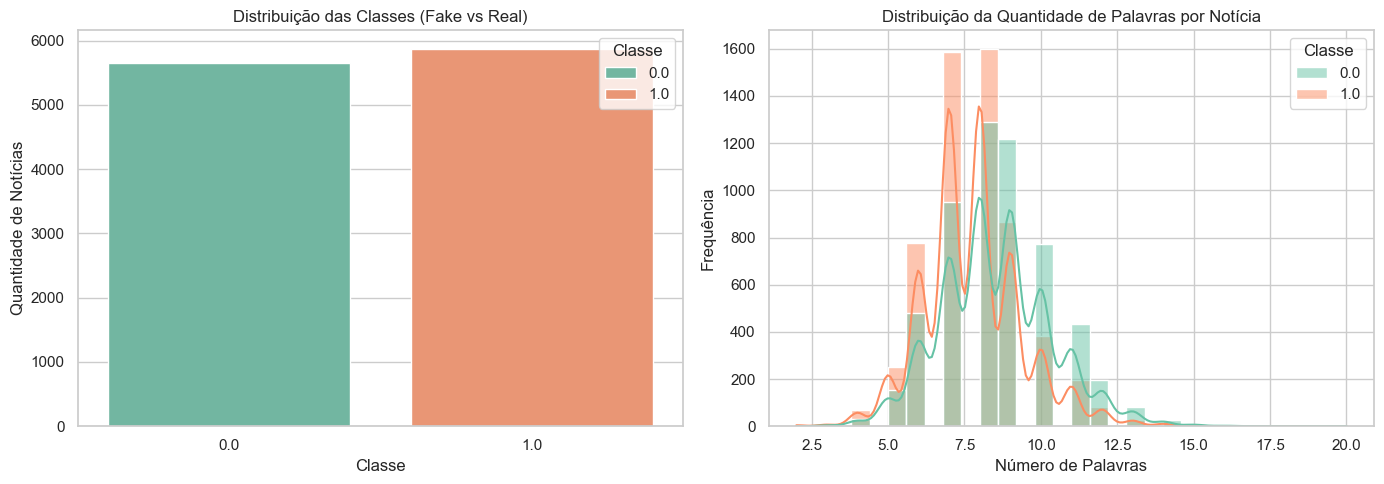


📊 Estatísticas da quantidade de palavras por notícia:
         count      mean       std  min  25%  50%   75%   max
Classe                                                       
0.0     5655.0  8.531565  1.810149  3.0  7.0  8.0  10.0  20.0
1.0     5866.0  7.756222  1.596533  2.0  7.0  8.0   9.0  17.0


In [4]:
# Contagem de palavras por notícia
df_clean["qtd_palavras"] = df_clean["texto_limpo"].apply(lambda x: len(x.split()))

# Figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico de Balanceamento de Classes
sns.countplot(
    data=df_clean, x=COLUNA_ALVO, ax=axes[0], palette="Set2", hue=COLUNA_ALVO
)
axes[0].set_title("Distribuição das Classes (Fake vs Real)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de Notícias")

# 2. Histograma do Tamanho dos Textos
sns.histplot(
    data=df_clean,
    x="qtd_palavras",
    hue=COLUNA_ALVO,
    kde=True,
    ax=axes[1],
    palette="Set2",
    bins=30,
)
axes[1].set_title("Distribuição da Quantidade de Palavras por Notícia")
axes[1].set_xlabel("Número de Palavras")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# Resumo Estatístico do Tamanho das Notícias
print("\n📊 Estatísticas da quantidade de palavras por notícia:")
print(df_clean.groupby(COLUNA_ALVO)["qtd_palavras"].describe())

## 5. Divisão Estratificada (Holdout 80/20) — Blindagem contra Data Leakage

#### Para evitar qualquer vazamento de informação do conjunto de teste na etapa de vetorização (TF-IDF), a separação é realizada **agora**, antes do treino no Notebook 02.

In [5]:
X = df_clean["texto_limpo"]
y = df_clean[COLUNA_ALVO]

# Divisão estratificada: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Consolidação em DataFrames
df_train = pd.DataFrame({"texto_limpo": X_train, "label": y_train})
df_test = pd.DataFrame({"texto_limpo": X_test, "label": y_test})

print(
    "✅ Separação concluída com sucesso mantendo a proporção de classes"
    " (stratify):"
)
print(f"• Dataset de Treino (80%): {len(df_train)} amostras")
print(f"• Dataset de Teste Holdout (20%): {len(df_test)} amostras")

✅ Separação concluída com sucesso mantendo a proporção de classes (stratify):
• Dataset de Treino (80%): 9216 amostras
• Dataset de Teste Holdout (20%): 2305 amostras


## 6. Exportação dos Datasets Processados

### Salva os DataFrames de treino e teste em disco no diretório `data/processed/`.

In [6]:
# Criar diretório de saída caso não exista
OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(OUTPUT_DIR, "train.csv")
TEST_FILE = os.path.join(OUTPUT_DIR, "test_holdout.csv")

# Salvar arquivos CSV
df_train.to_csv(TRAIN_FILE, index=False)
df_test.to_csv(TEST_FILE, index=False)

print(f"💾 Dataset de Treino salvo em: '{TRAIN_FILE}'")
print(f"💾 Dataset de Teste Holdout salvo em: '{TEST_FILE}'")
print("\n🚀 Notebook 01 concluído! Próximo passo: Notebook 02 (Treino & CV).")

💾 Dataset de Treino salvo em: 'data/processed\train.csv'
💾 Dataset de Teste Holdout salvo em: 'data/processed\test_holdout.csv'

🚀 Notebook 01 concluído! Próximo passo: Notebook 02 (Treino & CV).
